In [ ]:
import nltk
import matplotlib.pyplot as plt
import torch
import numpy as np
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
from google.colab import drive

drive.mount('/content/drive')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

file_path = '/content/drive/MyDrive/corpus.txt'

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total Tokens: 90874
Total Types (Unique Words): 8871
Type-Token Ratio: 0.0976


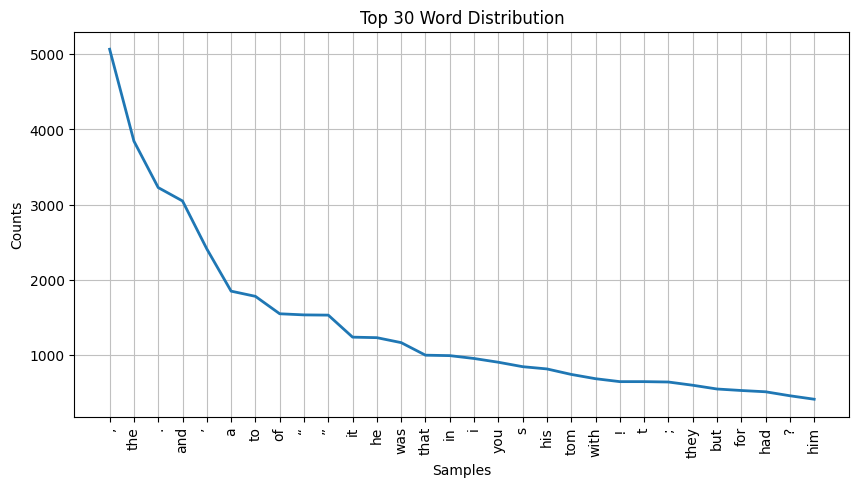

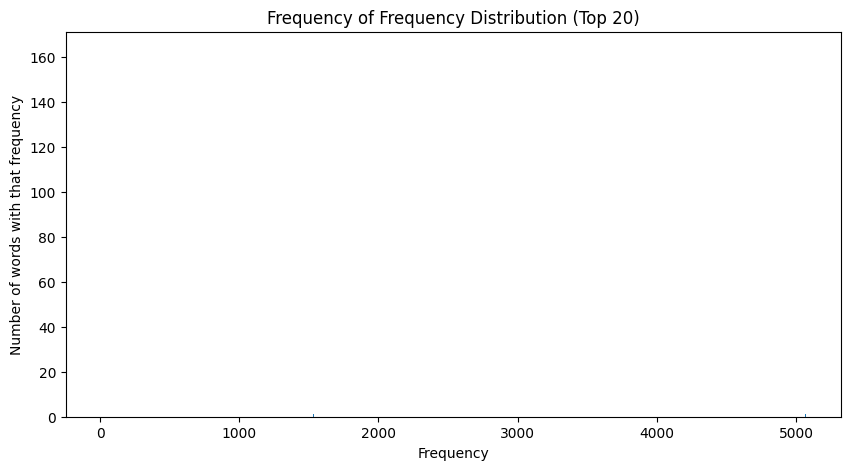

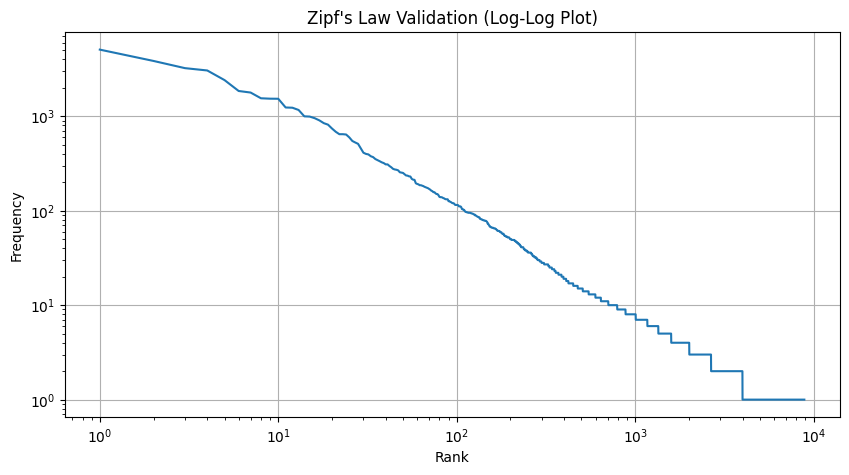

In [ ]:
#Assignment 1
with open(file_path, 'r', encoding='utf-8') as f:
    raw_text = f.read()


tokens = word_tokenize(raw_text.lower())
types = set(tokens)


ttr = len(types) / len(tokens)
print(f"Total Tokens: {len(tokens)}")
print(f"Total Types (Unique Words): {len(types)}")
print(f"Type-Token Ratio: {ttr:.4f}")


fdist = FreqDist(tokens)
plt.figure(figsize=(10, 5))
fdist.plot(30, title="Top 30 Word Distribution")


freq_of_freq = FreqDist(fdist.values())
plt.figure(figsize=(10, 5))
plt.bar(list(freq_of_freq.keys())[:20], list(freq_of_freq.values())[:20])
plt.title("Frequency of Frequency Distribution (Top 20)")
plt.xlabel("Frequency")
plt.ylabel("Number of words with that frequency")
plt.show()


ranks = np.arange(1, len(fdist) + 1)
frequencies = sorted(fdist.values(), reverse=True)

plt.figure(figsize=(10, 5))
plt.loglog(ranks, frequencies)
plt.title("Zipf's Law Validation (Log-Log Plot)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
import nltk
import matplotlib.pyplot as plt
import torch
import numpy as np
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
from google.colab import drive

# 1. Mount Google Drive and Download Resources
drive.mount('/content/drive')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# PATH TO YOUR FILE - Ensure this is correct for your Drive
file_path = '/content/drive/MyDrive/corpus.txt'

# Load the actual corpus content [cite: 58]
with open(file_path, 'r', encoding='utf-8') as f:
    corpus_text = f.read()



# --- Assignment 2: Preprocessing the corpus.txt ---
# [cite: 70, 71, 72, 73, 74, 75, 76]

# 1. Sentence and Word Tokenization [cite: 70, 71]
sentences = sent_tokenize(corpus_text)
words = word_tokenize(corpus_text)

# 2. Lowercasing and Punctuation Removal [cite: 72, 73]
# We use .isalnum() to keep only alphanumeric characters [cite: 33]
clean_tokens = [w.lower() for w in words if w.isalnum()]

# 3. Stopword Removal [cite: 74]
stop_words = set(stopwords.words('english'))
final_words = [w for w in clean_tokens if w not in stop_words]

print(f"\n--- Assignment 2 Results ---")
print(f"Total words after cleaning: {len(final_words)}") # [cite: 75]
print("Top 10 most frequent words:")
print(FreqDist(final_words).most_common(10)) #

# --- Assignment 3: Frequency & WordNet ---
# [cite: 78, 79]

print(f"\n--- Assignment 3 Results ---")
# Question 1: Frequency Distribution [cite: 78]
fdist = FreqDist(final_words)
print("Frequency Distribution computed for the entire corpus.")

# Question 2: WordNet Synonyms/Antonyms
# Note: WordNet requires a specific word to lookup
target_word = "study" # You can change this to any word found in your corpus
synonyms = []
antonyms = []

for syn in wordnet.synsets(target_word):
    for l in syn.lemmas():
        synonyms.append(l.name())
        if l.antonyms():
            antonyms.append(l.antonyms()[0].name())

print(f"Synonyms for '{target_word}': {set(synonyms)}")
print(f"Antonyms for '{target_word}': {set(antonyms)}")

# Questions 3 & 4: PyTorch Operations [cite: 80, 85]
# (These tasks are independent of the text file)
tensor_2d = torch.randint(0, 10, (3, 4)) # [cite: 88]
print(f"\nPyTorch 2D Tensor:\n{tensor_2d}")
print(f"2x2 Submatrix:\n{tensor_2d[0:2, 0:2]}") # [cite: 89]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



--- Assignment 2 Results ---
Total words after cleaning: 33583
Top 10 most frequent words:
[('tom', 741), ('said', 352), ('would', 236), ('huck', 231), ('one', 184), ('could', 177), ('time', 175), ('got', 170), ('well', 157), ('joe', 157)]

--- Assignment 3 Results ---
Frequency Distribution computed for the entire corpus.
Synonyms for 'study': {'analyze', 'examine', 'work', 'report', 'study', 'cogitation', 'analyse', 'read', 'discipline', 'learn', 'survey', 'take', 'bailiwick', 'canvass', 'sketch', 'field', 'meditate', 'hit_the_books', 'contemplate', 'subject_area', 'canvas', 'field_of_study', 'written_report', 'subject_field', 'consider', 'subject'}
Antonyms for 'study': set()

PyTorch 2D Tensor:
tensor([[9, 5, 7, 9],
        [6, 2, 2, 8],
        [3, 5, 9, 5]])
2x2 Submatrix:
tensor([[9, 5],
        [6, 2]])


In [ ]:
# --- Assignment 2 ---
paragraph = """Natural Language Processing (NLP) is a branch of Artificial Intelligence that focuses on the interaction between computers and humans using natural language. NLP techniques are widely used in applications such as chatbots, machine translation, sentiment analysis, and information retrieval. By using libraries like NLTK, developers can tokenize text, remove stopwords, and analyze linguistic patterns efficiently. As data grows rapidly, NLP plays a crucial role in extracting meaningful insights from unstructured text data."""

sentences = sent_tokenize(paragraph)
print(f"Sentences: {sentences}")

words = word_tokenize(paragraph)

words_lower = [w.lower() for w in words]

words_no_punc = [w for w in words_lower if w.isalnum()]

stop_words = set(stopwords.words('english'))
cleaned_words = [w for w in words_no_punc if w not in stop_words]

print(f"\nTotal words after preprocessing: {len(cleaned_words)}")
print("Top 10 most frequent words:")
print(FreqDist(cleaned_words).most_common(10))

Sentences: ['Natural Language Processing (NLP) is a branch of Artificial Intelligence that focuses on the interaction between computers and humans using natural language.', 'NLP techniques are widely used in applications such as chatbots, machine translation, sentiment analysis, and information retrieval.', 'By using libraries like NLTK, developers can tokenize text, remove stopwords, and analyze linguistic patterns efficiently.', 'As data grows rapidly, NLP plays a crucial role in extracting meaningful insights from unstructured text data.']

Total words after preprocessing: 52
Top 10 most frequent words:
[('nlp', 3), ('natural', 2), ('language', 2), ('using', 2), ('text', 2), ('data', 2), ('processing', 1), ('branch', 1), ('artificial', 1), ('intelligence', 1)]


In [ ]:
# --- Assignment 3 ---

# Q2: Synonyms and Antonyms using WordNet [cite: 79]
def get_syn_ant(word):
    synonyms = []
    antonyms = []
    for syn in wordnet.synsets(word):
        for l in syn.lemmas():
            synonyms.append(l.name())
            if l.antonyms():
                antonyms.append(l.antonyms()[0].name())
    return set(synonyms), set(antonyms)

word = "happy"
syns, ants = get_syn_ant(word)
print(f"\nWord: {word}")
print(f"Synonyms: {syns}")
print(f"Antonyms: {ants}")

# Q3: PyTorch Tensor Operations [cite: 80, 81, 82, 83, 84]
tensor_a = torch.rand(5, 3)
print(f"\nTensor Shape: {tensor_a.shape}")
tensor_b = tensor_a * 2  # Mathematical operation
print(f"Sum of all elements: {tensor_b.sum().item():.4f}")

# Q4: PyTorch Indexing and Slicing [cite: 85, 86, 87, 88, 89]
# 1D Tensor 10 to 19
tensor_1d = torch.arange(10, 20)
print(f"\n1D Tensor: {tensor_1d}")
print(f"First: {tensor_1d[0]}, Last: {tensor_1d[-1]}, Middle: {tensor_1d[4:6]}")

# 2D Tensor (3,4)
tensor_2d = torch.randint(0, 10, (3, 4))
print(f"2D Tensor:\n{tensor_2d}")
print(f"First Row: {tensor_2d[0, :]}")
print(f"Last Column: {tensor_2d[:, -1]}")
print(f"2x2 Submatrix:\n{tensor_2d[0:2, 0:2]}")


Word: happy
Synonyms: {'well-chosen', 'felicitous', 'happy', 'glad'}
Antonyms: {'unhappy'}

Tensor Shape: torch.Size([5, 3])
Sum of all elements: 15.6772

1D Tensor: tensor([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
First: 10, Last: 19, Middle: tensor([14, 15])
2D Tensor:
tensor([[0, 2, 4, 9],
        [1, 8, 4, 3],
        [6, 9, 4, 2]])
First Row: tensor([0, 2, 4, 9])
Last Column: tensor([9, 3, 2])
2x2 Submatrix:
tensor([[0, 2],
        [1, 8]])
